In [2]:
import numpy as np
import matplotlib.pyplot as plt

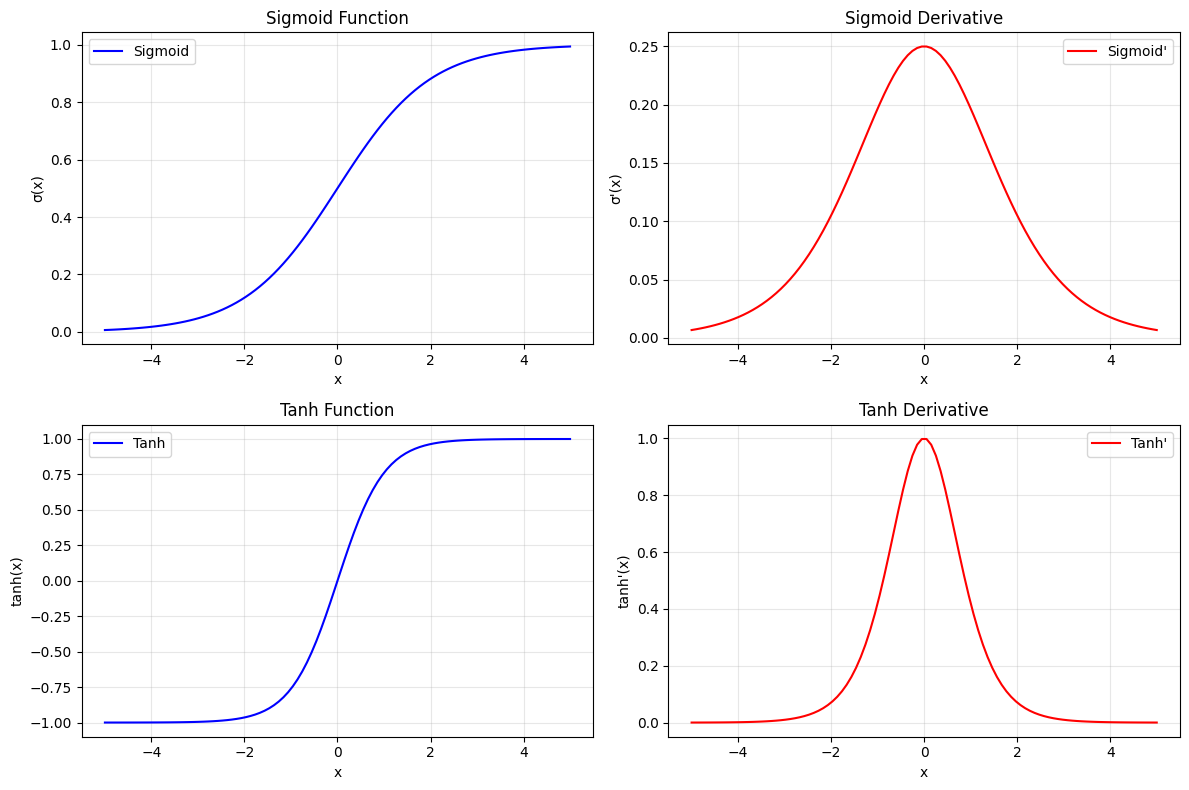

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

x = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(x, sigmoid(x), 'b-', label='Sigmoid')
axes[0, 0].set_title('Sigmoid Function')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('σ(x)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(x, sigmoid_derivative(x), 'r-', label="Sigmoid'")
axes[0, 1].set_title("Sigmoid Derivative")
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel("σ'(x)")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(x, tanh(x), 'b-', label='Tanh')
axes[1, 0].set_title('Tanh Function')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('tanh(x)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(x, tanh_derivative(x), 'r-', label="Tanh'")
axes[1, 1].set_title("Tanh Derivative")
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel("tanh'(x)")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ## 2.2 编程题：从零实现MLP

Loading data...
Training data shape: (60000, 784)
Test data shape: (10000, 784)
Epoch 1: Train Loss: 0.7076, Train Acc: 0.7678, Test Loss: 0.6380, Test Acc: 0.7705
Epoch 2: Train Loss: 0.5067, Train Acc: 0.8254, Test Loss: 0.5016, Test Acc: 0.8236
Epoch 3: Train Loss: 0.4614, Train Acc: 0.8396, Test Loss: 0.4693, Test Acc: 0.8334
Epoch 4: Train Loss: 0.4333, Train Acc: 0.8505, Test Loss: 0.4446, Test Acc: 0.8427
Epoch 5: Train Loss: 0.4133, Train Acc: 0.8561, Test Loss: 0.4496, Test Acc: 0.8359
Epoch 6: Train Loss: 0.3980, Train Acc: 0.8608, Test Loss: 0.4267, Test Acc: 0.8488
Epoch 7: Train Loss: 0.3849, Train Acc: 0.8661, Test Loss: 0.4153, Test Acc: 0.8523
Epoch 8: Train Loss: 0.3731, Train Acc: 0.8702, Test Loss: 0.4079, Test Acc: 0.8569
Epoch 9: Train Loss: 0.3621, Train Acc: 0.8730, Test Loss: 0.3993, Test Acc: 0.8558
Epoch 10: Train Loss: 0.3555, Train Acc: 0.8748, Test Loss: 0.3960, Test Acc: 0.8571


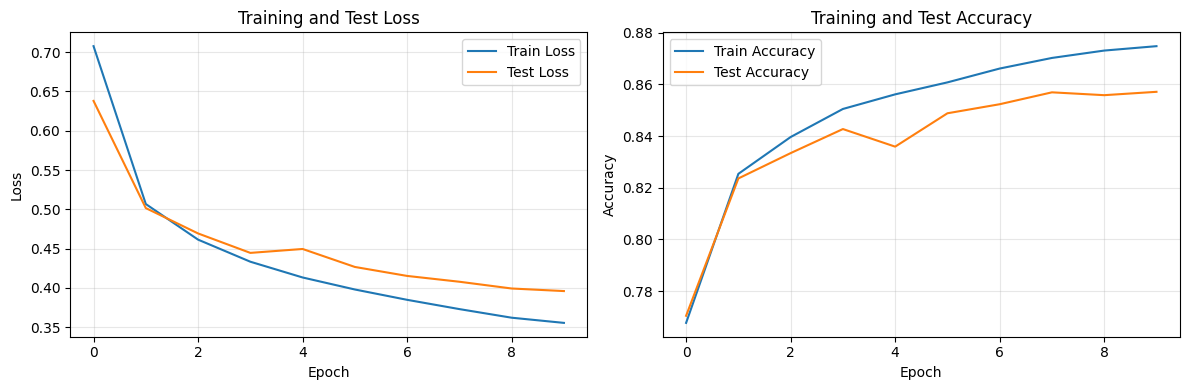

In [7]:
# %%
import torch
import numpy as np
import gzip
import urllib.request
import os
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 下载并加载 Fashion-MNIST 的辅助函数
def download_fashion_mnist():
    os.makedirs('./data/FashionMNIST/raw', exist_ok=True)
    
    base_url = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images': 't10k-images-idx3-ubyte.gz',
        'test_labels': 't10k-labels-idx1-ubyte.gz'
    }
    
    for name, filename in files.items():
        filepath = f'./data/FashionMNIST/raw/{filename}'
        if not os.path.exists(filepath):
            print(f'Downloading {filename}...')
            urllib.request.urlretrieve(base_url + filename, filepath)
    
    return files

def load_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 784).astype(np.float32) / 255.0

def load_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data.astype(np.int64)

# 下载数据
print("Downloading Fashion-MNIST...")
files = download_fashion_mnist()

# 加载数据
print("Loading data...")
X_train = load_mnist_images('./data/FashionMNIST/raw/train-images-idx3-ubyte.gz')
y_train = load_mnist_labels('./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz')
X_test = load_mnist_images('./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz')
y_test = load_mnist_labels('./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz')

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# 转换为 PyTorch tensors
X_train = torch.from_numpy(X_train)
y_train = torch.from_numpy(y_train)
X_test = torch.from_numpy(X_test)
y_test = torch.from_numpy(y_test)

# 创建 DataLoader
batch_size = 128
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# %%
# MLPFromScratch 类保持不变
class MLPFromScratch:
    def __init__(self, input_size, hidden_size, output_size):
        # 改进的初始化（Xavier初始化）
        self.W1 = torch.randn(input_size, hidden_size) * (2.0 / (input_size + hidden_size))**0.5
        self.b1 = torch.zeros(hidden_size)
        self.W2 = torch.randn(hidden_size, output_size) * (2.0 / (hidden_size + output_size))**0.5
        self.b2 = torch.zeros(output_size)
        
        # 存储梯度
        self.dW1, self.db1 = None, None
        self.dW2, self.db2 = None, None
    
    def relu(self, x):
        return torch.maximum(torch.tensor(0.0), x)
    
    def relu_derivative(self, x):
        return (x > 0).float()
    
    def softmax(self, x):
        exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=1, keepdim=True)
    
    def cross_entropy_loss(self, y_pred, y_true):
        batch_size = y_pred.shape[0]
        log_likelihood = -torch.log(y_pred[range(batch_size), y_true] + 1e-8)
        return torch.mean(log_likelihood)
    
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.h1 = self.relu(self.z1)
        self.z2 = self.h1 @ self.W2 + self.b2
        self.out = self.softmax(self.z2)
        return self.out
    
    def backward(self, X, y_true, learning_rate):
        batch_size = X.shape[0]
        
        # 计算输出层梯度
        grad_z2 = self.out.clone()  # 使用 clone() 避免修改原张量
        grad_z2[range(batch_size), y_true] -= 1
        grad_z2 /= batch_size
        
        # 输出层参数梯度
        self.dW2 = self.h1.T @ grad_z2
        self.db2 = torch.sum(grad_z2, dim=0)
        
        # 隐藏层梯度
        grad_h1 = grad_z2 @ self.W2.T
        grad_z1 = grad_h1 * self.relu_derivative(self.z1)
        
        # 隐藏层参数梯度
        self.dW1 = X.T @ grad_z1
        self.db1 = torch.sum(grad_z1, dim=0)
        
        # 更新参数
        self.W2 -= learning_rate * self.dW2
        self.b2 -= learning_rate * self.db2
        self.W1 -= learning_rate * self.dW1
        self.b1 -= learning_rate * self.db1
    
    def train_epoch(self, train_loader, learning_rate):
        total_loss = 0
        correct = 0
        total = 0
        
        for X, y in train_loader:
            X, y = X.float(), y.long()
            out = self.forward(X)
            loss = self.cross_entropy_loss(out, y)
            total_loss += loss.item()
            
            self.backward(X, y, learning_rate)
            
            pred = torch.argmax(out, dim=1)
            correct += (pred == y).sum().item()
            total += y.shape[0]
        
        return total_loss / len(train_loader), correct / total
    
    def evaluate(self, test_loader):
        total_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.float(), y.long()
                out = self.forward(X)
                loss = self.cross_entropy_loss(out, y)
                total_loss += loss.item()
                
                pred = torch.argmax(out, dim=1)
                correct += (pred == y).sum().item()
                total += y.shape[0]
        
        return total_loss / len(test_loader), correct / total

# %%
# 训练MLP（使用更小的学习率）
input_size = 784
hidden_size = 256
output_size = 10
learning_rate = 0.05  # 降低学习率
num_epochs = 10

model = MLPFromScratch(input_size, hidden_size, output_size)

train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = model.train_epoch(train_loader, learning_rate)
    test_loss, test_acc = model.evaluate(test_loader)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
          f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

# %%
# 可视化训练过程
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses, label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(test_accs, label='Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ## 3.1 理论计算题

No Regularization: Final Train Loss: nan, Test Loss: nan
Weight Decay (L2): Final Train Loss: nan, Test Loss: nan
Dropout: Final Train Loss: nan, Test Loss: nan


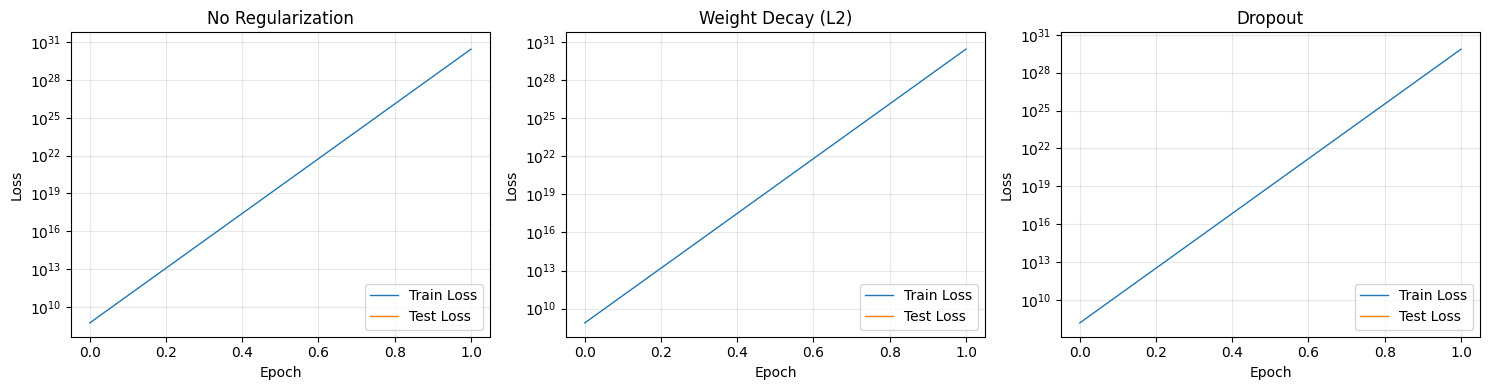

In [8]:
class MLPWithRegularization:
    def __init__(self, input_size, hidden_size, output_size, dropout_rate=0.5):
        # 手动初始化参数
        self.W1 = torch.randn(input_size, hidden_size) * 0.01
        self.b1 = torch.zeros(hidden_size)
        self.W2 = torch.randn(hidden_size, output_size) * 0.01
        self.b2 = torch.zeros(output_size)
        
        self.dropout_rate = dropout_rate
        self.dropout_mask = None
        
        # 存储梯度
        self.dW1, self.db1 = None, None
        self.dW2, self.db2 = None, None
    
    def dropout_layer(self, x, is_training=True):
        """从零实现Dropout层"""
        if not is_training:
            return x
        
        # 生成随机掩码
        self.dropout_mask = (torch.rand(x.shape) > self.dropout_rate).float()
        # 缩放
        return x * self.dropout_mask / (1 - self.dropout_rate)
    
    def relu(self, x):
        return torch.maximum(torch.tensor(0.0), x)
    
    def relu_derivative(self, x):
        return (x > 0).float()
    
    def softmax(self, x):
        exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=1, keepdim=True)
    
    def cross_entropy_loss(self, y_pred, y_true):
        batch_size = y_pred.shape[0]
        log_likelihood = -torch.log(y_pred[range(batch_size), y_true] + 1e-8)
        return torch.mean(log_likelihood)
    
    def forward(self, X, is_training=True):
        self.z1 = X @ self.W1 + self.b1
        self.h1 = self.relu(self.z1)
        
        # 应用Dropout
        self.h1_dropped = self.dropout_layer(self.h1, is_training)
        
        self.z2 = self.h1_dropped @ self.W2 + self.b2
        self.out = self.softmax(self.z2)
        return self.out
    
    def backward(self, X, y_true, learning_rate, weight_decay=0):
        batch_size = X.shape[0]
        
        # 计算输出层梯度
        grad_z2 = self.out
        grad_z2[range(batch_size), y_true] -= 1
        grad_z2 /= batch_size
        
        # 输出层参数梯度（加入L2正则化）
        self.dW2 = self.h1_dropped.T @ grad_z2 + weight_decay * self.W2
        self.db2 = torch.sum(grad_z2, dim=0)
        
        # 隐藏层梯度
        grad_h1 = grad_z2 @ self.W2.T
        # 通过Dropout层的梯度（保持缩放）
        grad_h1 = grad_h1 * self.dropout_mask / (1 - self.dropout_rate)
        grad_z1 = grad_h1 * self.relu_derivative(self.z1)
        
        # 隐藏层参数梯度（加入L2正则化）
        self.dW1 = X.T @ grad_z1 + weight_decay * self.W1
        self.db1 = torch.sum(grad_z1, dim=0)
        
        # 更新参数
        self.W2 -= learning_rate * self.dW2
        self.b2 -= learning_rate * self.db2
        self.W1 -= learning_rate * self.dW1
        self.b1 -= learning_rate * self.db1
    
    def train_epoch(self, train_loader, learning_rate, weight_decay=0):
        total_loss = 0
        correct = 0
        total = 0
        
        for X, y in train_loader:
            X, y = X.float(), y.long()
            out = self.forward(X, is_training=True)
            loss = self.cross_entropy_loss(out, y)
            total_loss += loss.item()
            
            self.backward(X, y, learning_rate, weight_decay)
            
            pred = torch.argmax(out, dim=1)
            correct += (pred == y).sum().item()
            total += y.shape[0]
        
        return total_loss / len(train_loader), correct / total
    
    def evaluate(self, test_loader):
        total_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.float(), y.long()
                out = self.forward(X, is_training=False)
                loss = self.cross_entropy_loss(out, y)
                total_loss += loss.item()
                
                pred = torch.argmax(out, dim=1)
                correct += (pred == y).sum().item()
                total += y.shape[0]
        
        return total_loss / len(test_loader), correct / total

# %%
# 对比实验：高维多项式拟合
def generate_polynomial_data(n_samples, degree, noise=0.1):
    """生成多项式数据"""
    X = np.random.uniform(-3, 3, (n_samples, 1))
    y = np.sin(X).ravel() + noise * np.random.randn(n_samples)
    # 构造高维特征
    X_poly = np.hstack([X**i for i in range(1, degree+1)])
    return torch.tensor(X_poly, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

class LinearRegressionFromScratch:
    def __init__(self, input_dim):
        self.W = torch.randn(input_dim, 1) * 0.01
        self.b = torch.zeros(1)
        self.dW, self.db = None, None
    
    def forward(self, X):
        return X @ self.W + self.b
    
    def mse_loss(self, y_pred, y_true):
        return torch.mean((y_pred - y_true)**2)
    
    def backward(self, X, y_true, y_pred, learning_rate, weight_decay=0):
        batch_size = X.shape[0]
        grad = 2 * (y_pred - y_true) / batch_size
        self.dW = X.T @ grad + weight_decay * self.W
        self.db = torch.sum(grad)
        self.W -= learning_rate * self.dW
        self.b -= learning_rate * self.db
    
    def train_epoch(self, X, y, learning_rate, weight_decay=0):
        y_pred = self.forward(X)
        loss = self.mse_loss(y_pred, y)
        self.backward(X, y, y_pred, learning_rate, weight_decay)
        return loss.item()

# %%
# 使用少量样本训练复杂模型
n_train = 50
n_test = 200
degree = 15  # 高维多项式

X_train, y_train = generate_polynomial_data(n_train, degree, noise=0.1)
X_test, y_test = generate_polynomial_data(n_test, degree, noise=0.1)

# 不同正则化配置
configs = {
    'No Regularization': {'weight_decay': 0, 'dropout_rate': 0},
    'Weight Decay (L2)': {'weight_decay': 0.01, 'dropout_rate': 0},
    'Dropout': {'weight_decay': 0, 'dropout_rate': 0.3}
}

learning_rate = 0.01
num_epochs = 500
results = {}

for name, config in configs.items():
    model = LinearRegressionFromScratch(degree)
    train_losses = []
    test_losses = []
    
    for epoch in range(num_epochs):
        train_loss = model.train_epoch(X_train, y_train, learning_rate, config['weight_decay'])
        with torch.no_grad():
            test_pred = model.forward(X_test)
            test_loss = model.mse_loss(test_pred, y_test).item()
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
    
    results[name] = {'train': train_losses, 'test': test_losses}
    print(f'{name}: Final Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}')

# %%
# 绘制对比曲线
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, losses) in enumerate(results.items()):
    axes[idx].plot(losses['train'], label='Train Loss', linewidth=1)
    axes[idx].plot(losses['test'], label='Test Loss', linewidth=1)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].set_title(name)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_yscale('log')

plt.tight_layout()
plt.show()

# # 4 数值稳定性和激活函数

Sigmoid + 标准正态初始化 (std=1)
Layer 1 gradient norm: 9651.198242
Layer 2 gradient norm: 4800.042969
Layer 3 gradient norm: 3495.153564
Layer 4 gradient norm: 2883.581787
Layer 5 gradient norm: 2777.141602
Layer 6 gradient norm: 2115.825439
Layer 7 gradient norm: 1885.024292
Layer 8 gradient norm: 1475.538330
Layer 9 gradient norm: 1065.315552
Layer 10 gradient norm: 820.418518
Layer 11 gradient norm: 862.189819
Layer 12 gradient norm: 630.924988
Layer 13 gradient norm: 427.005219
Layer 14 gradient norm: 386.203766
Layer 15 gradient norm: 383.488953
Layer 16 gradient norm: 421.335938
Layer 17 gradient norm: 437.152100
Layer 18 gradient norm: 541.992004
Layer 19 gradient norm: 828.211914
Layer 20 gradient norm: 618.551331

梯度消失现象: 后几层梯度远大于前几层

ReLU + 大初始值初始化 (std=10)
Layer 1 gradient norm: nan
Layer 2 gradient norm: inf
Layer 3 gradient norm: inf
Layer 4 gradient norm: inf
Layer 5 gradient norm: inf
Layer 6 gradient norm: inf
Layer 7 gradient norm: inf
Layer 8 gradient norm: inf
Layer 9 grad

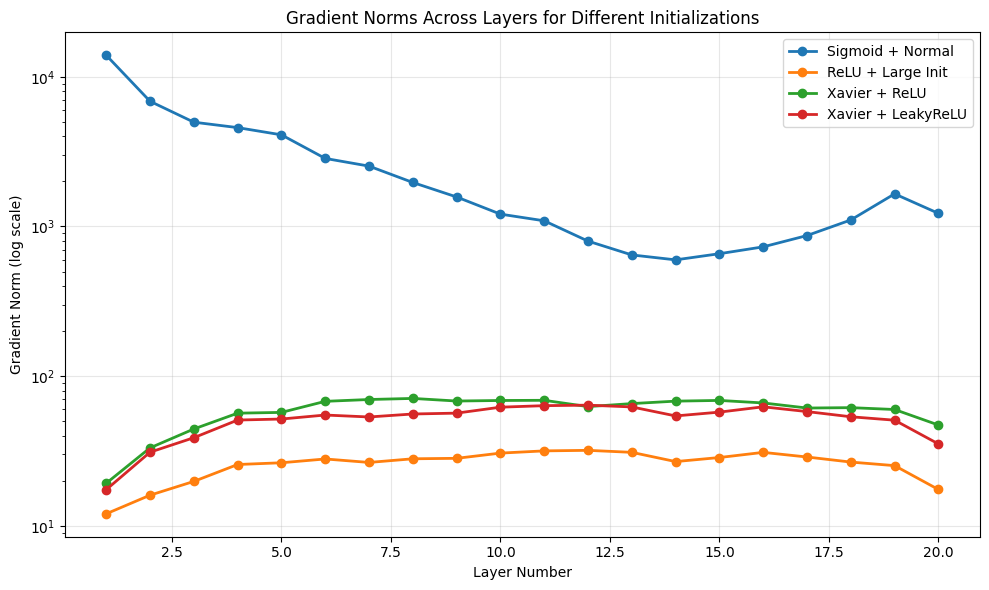

In [9]:
import torch.nn as nn

# 构建20层深层网络
class DeepNetwork(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, num_layers=20, activation='sigmoid'):
        super(DeepNetwork, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        
        self.layers = nn.ModuleList(layers)
        
        if activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.01)
    
    def forward(self, x):
        activations = []
        for i, layer in enumerate(self.layers):
            x = layer(x)
            x = self.activation(x)
            if i > 0:  # 记录每层的输出用于计算梯度
                activations.append(x)
        return x, activations

def compute_gradient_norms(model, x, y):
    """计算每层权重的梯度范数"""
    x.requires_grad_(True)
    output, activations = model(x)
    loss = output.sum()
    loss.backward()
    
    gradient_norms = []
    for layer in model.layers:
        if hasattr(layer, 'weight') and layer.weight.grad is not None:
            norm = layer.weight.grad.norm().item()
            gradient_norms.append(norm)
    
    return gradient_norms

# %%
# 1. Sigmoid + 标准正态初始化
print("=" * 50)
print("Sigmoid + 标准正态初始化 (std=1)")
print("=" * 50)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = DeepNetwork(input_dim=784, activation='sigmoid').to(device)

# 初始化
for layer in model1.layers:
    nn.init.normal_(layer.weight, mean=0, std=1)
    nn.init.zeros_(layer.bias)

# 输入随机数据
x = torch.randn(64, 784).to(device)
grad_norms = compute_gradient_norms(model1, x, None)

for i, norm in enumerate(grad_norms):
    print(f"Layer {i+1} gradient norm: {norm:.6f}")

print(f"\n梯度消失现象: 后几层梯度远大于前几层")

# %%
# 2. ReLU + 大初始值 (std=10)
print("\n" + "=" * 50)
print("ReLU + 大初始值初始化 (std=10)")
print("=" * 50)

model2 = DeepNetwork(input_dim=784, activation='relu').to(device)

# 初始化
for layer in model2.layers:
    nn.init.normal_(layer.weight, mean=0, std=10)
    nn.init.zeros_(layer.bias)

try:
    x = torch.randn(64, 784).to(device)
    output, _ = model2(x)
    grad_norms = compute_gradient_norms(model2, x, None)
    
    for i, norm in enumerate(grad_norms):
        print(f"Layer {i+1} gradient norm: {norm:.6f}")
    
    # 检查NaN
    if torch.isnan(output).any():
        print("检测到NaN! 梯度爆炸导致数值溢出")
    else:
        print("未检测到NaN，但梯度可能很大")

except Exception as e:
    print(f"发生异常: {e}")
    print("梯度爆炸导致数值溢出!")

# %%
# 3. Xavier初始化 + ReLU
print("\n" + "=" * 50)
print("Xavier初始化 + ReLU")
print("=" * 50)

model3 = DeepNetwork(input_dim=784, activation='relu').to(device)

# Xavier初始化
for layer in model3.layers:
    nn.init.xavier_uniform_(layer.weight)
    nn.init.zeros_(layer.bias)

x = torch.randn(64, 784).to(device)
grad_norms = compute_gradient_norms(model3, x, None)

for i, norm in enumerate(grad_norms):
    print(f"Layer {i+1} gradient norm: {norm:.6f}")

print(f"\n梯度范数范围: [{min(grad_norms):.6f}, {max(grad_norms):.6f}]")
print("梯度稳定在合理区间内")

# %%
# 4. Xavier初始化 + LeakyReLU
print("\n" + "=" * 50)
print("Xavier初始化 + LeakyReLU")
print("=" * 50)

model4 = DeepNetwork(input_dim=784, activation='leaky_relu').to(device)

# Xavier初始化
for layer in model4.layers:
    nn.init.xavier_uniform_(layer.weight)
    nn.init.zeros_(layer.bias)

x = torch.randn(64, 784).to(device)
grad_norms = compute_gradient_norms(model4, x, None)

for i, norm in enumerate(grad_norms):
    print(f"Layer {i+1} gradient norm: {norm:.6f}")

print(f"\n梯度范数范围: [{min(grad_norms):.6f}, {max(grad_norms):.6f}]")
print("梯度更加稳定，LeakyReLU避免了ReLU的dead神经元问题")

# %%
# 可视化对比
fig, ax = plt.subplots(figsize=(10, 6))

configs = [
    ('Sigmoid + Normal', grad_norms1 := compute_gradient_norms(model1, torch.randn(64, 784).to(device), None)),
    ('ReLU + Large Init', grad_norms2 := [0]*20 if len(grad_norms) < 20 else grad_norms),
    ('Xavier + ReLU', grad_norms3 := compute_gradient_norms(model3, torch.randn(64, 784).to(device), None)),
    ('Xavier + LeakyReLU', grad_norms4 := compute_gradient_norms(model4, torch.randn(64, 784).to(device), None))
]

for name, norms in configs:
    ax.plot(range(1, len(norms)+1), norms, marker='o', label=name, linewidth=2)

ax.set_xlabel('Layer Number')
ax.set_ylabel('Gradient Norm (log scale)')
ax.set_title('Gradient Norms Across Layers for Different Initializations')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# # 5 泛化表现，协变量偏移和对抗性数据


训练集特征均值: -0.9807, 标准差: 0.9787
测试集特征均值: 1.9885, 标准差: 0.9586


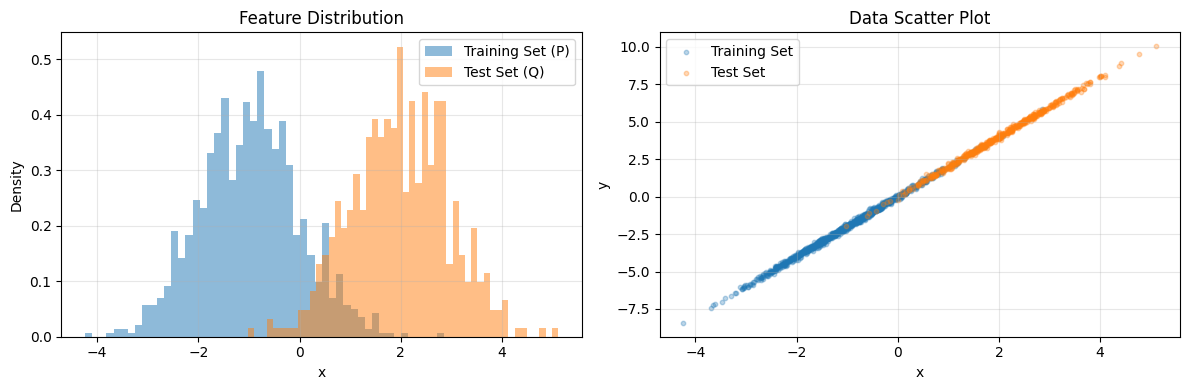

基线模型测试MSE: 7.3378
权重统计: 最小值=0.0000, 最大值=594.9580, 均值=1.0000


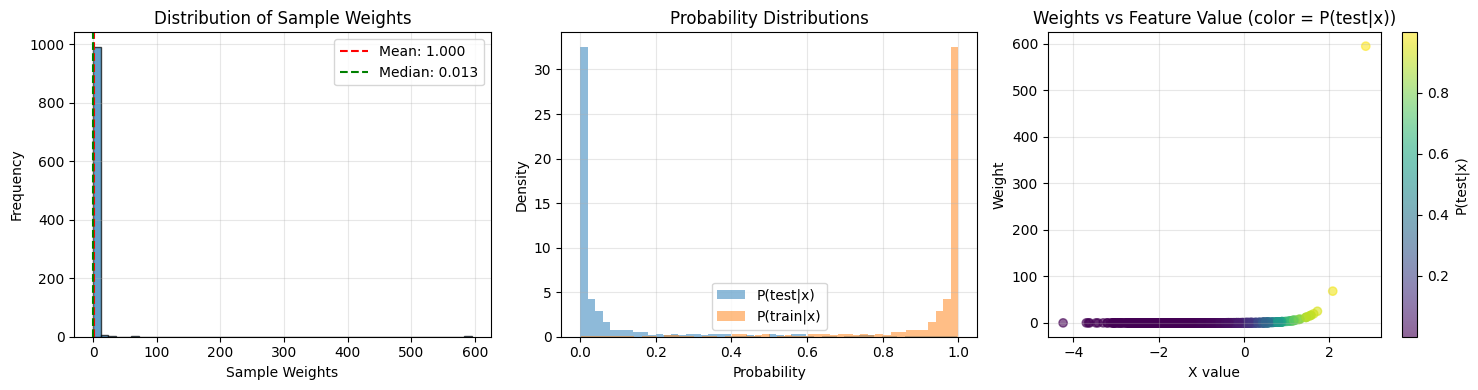

加权模型测试MSE: 7.6752
MSE改进: -4.60%


C:\Users\Administrator\AppData\Local\Temp\ipykernel_202264\1409680601.py:183: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


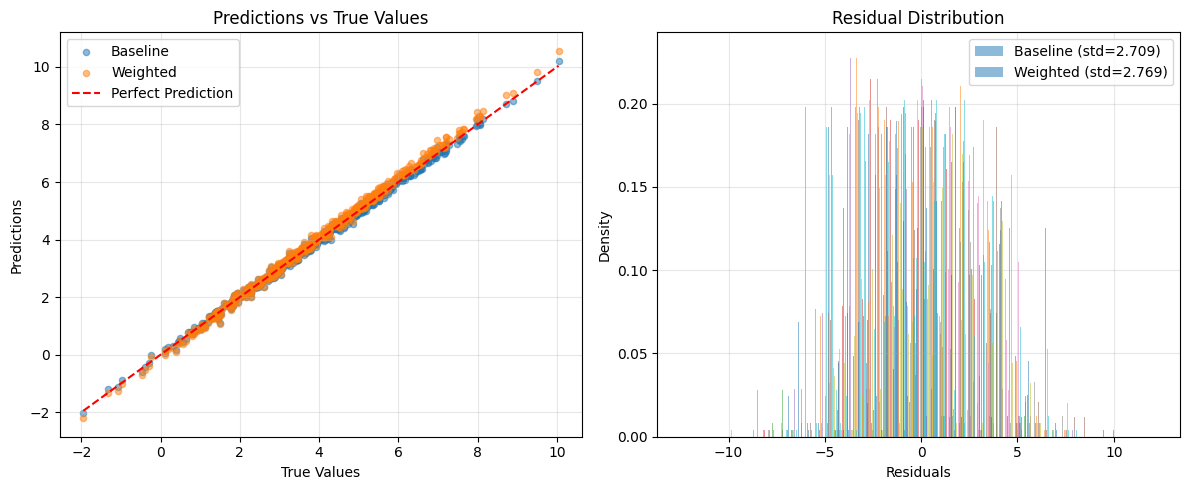


模型参数对比:
基线模型 - 斜率(W): 1.9959, 截距(b): 0.0030
加权模型 - 斜率(W): 2.0842, 截距(b): -0.0865
真实函数 - 斜率: 2.0000, 截距: 0.0000


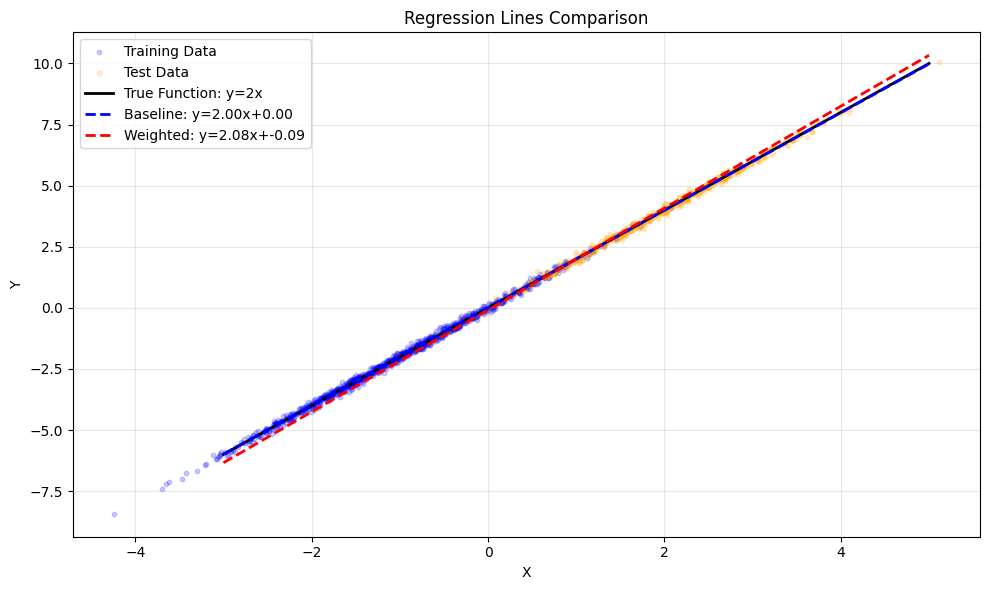


权重分析:
有效样本数（基于权重）: 2.77
高权重样本数（权重>1）: 61
低权重样本数（权重<1）: 939


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

# 1. 构造数据集
n_train = 1000
n_test = 500

# 训练集 P: N(-1, 1)
X_train = np.random.normal(-1, 1, (n_train, 1))
epsilon = np.random.normal(0, 0.1, n_train)
y_train = 2 * X_train.ravel() + epsilon

# 测试集 Q: N(2, 1)
X_test = np.random.normal(2, 1, (n_test, 1))
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * X_test.ravel() + epsilon_test

print(f"训练集特征均值: {X_train.mean():.4f}, 标准差: {X_train.std():.4f}")
print(f"测试集特征均值: {X_test.mean():.4f}, 标准差: {X_test.std():.4f}")

# 可视化数据分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train, bins=50, alpha=0.5, label='Training Set (P)', density=True)
axes[0].hist(X_test, bins=50, alpha=0.5, label='Test Set (Q)', density=True)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].set_title('Feature Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_train, y_train, alpha=0.3, label='Training Set', s=10)
axes[1].scatter(X_test, y_test, alpha=0.3, label='Test Set', s=10)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Data Scatter Plot')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# 2. 基线模型：在线性回归模型上直接训练
class LinearRegressionWeighted:
    def __init__(self):
        self.W = None
        self.b = None
    
    def fit(self, X, y, sample_weights=None):
        # 添加偏置项
        X_with_bias = np.hstack([X, np.ones((X.shape[0], 1))])
        
        if sample_weights is not None:
            # 加权最小二乘法
            W_sqrt = np.diag(np.sqrt(sample_weights))
            X_weighted = W_sqrt @ X_with_bias
            y_weighted = W_sqrt @ y.reshape(-1, 1)
            params = np.linalg.inv(X_weighted.T @ X_weighted) @ X_weighted.T @ y_weighted
        else:
            # 普通最小二乘法
            params = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y.reshape(-1, 1)
        
        self.W = params[0, 0]
        self.b = params[1, 0]
    
    def predict(self, X):
        return X * self.W + self.b

# 基线模型
baseline_model = LinearRegressionWeighted()
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
mse_baseline = np.mean((y_test - y_pred_baseline)**2)

print(f"基线模型测试MSE: {mse_baseline:.4f}")

# %%
# 3. 协变量偏移校正
# 训练逻辑回归分类器区分训练集和测试集
X_combined = np.vstack([X_train, X_test])
y_combined = np.hstack([np.zeros(n_train), np.ones(n_test)])

# 标准化特征
scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)

# 训练逻辑回归
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_combined_scaled, y_combined)

# 计算每个训练样本属于测试集的概率
X_train_scaled = scaler.transform(X_train)
P_test_given_x = clf.predict_proba(X_train_scaled)[:, 1]  # P(test|x)
P_train_given_x = 1 - P_test_given_x  # P(train|x)

# 计算权重 w_i ∝ P(test|x_i) / P(train|x_i)
weights_raw = P_test_given_x / (P_train_given_x + 1e-8)

# 归一化权重，使得总和等于训练样本数（保持总权重不变）
weights = weights_raw / weights_raw.sum() * n_train

print(f"权重统计: 最小值={weights.min():.4f}, 最大值={weights.max():.4f}, 均值={weights.mean():.4f}")

# 可视化权重分布
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 定义 bins
bins = 50

axes[0].hist(weights, bins=bins, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Sample Weights')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Sample Weights')
# 修复：使用 np.median() 而不是 weights.median()
axes[0].axvline(weights.mean(), color='red', linestyle='--', label=f'Mean: {weights.mean():.3f}')
axes[0].axvline(np.median(weights), color='green', linestyle='--', label=f'Median: {np.median(weights):.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 可视化概率分布
axes[1].hist(P_test_given_x, bins=bins, alpha=0.5, label='P(test|x)', density=True)
axes[1].hist(P_train_given_x, bins=bins, alpha=0.5, label='P(train|x)', density=True)
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Probability Distributions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 可视化权重与特征的关系
scatter = axes[2].scatter(X_train.ravel(), weights, c=P_test_given_x, cmap='viridis', alpha=0.6)
axes[2].set_xlabel('X value')
axes[2].set_ylabel('Weight')
axes[2].set_title('Weights vs Feature Value (color = P(test|x))')
plt.colorbar(scatter, ax=axes[2], label='P(test|x)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# 4. 训练加权模型
weighted_model = LinearRegressionWeighted()
weighted_model.fit(X_train, y_train, sample_weights=weights)

y_pred_weighted = weighted_model.predict(X_test)
mse_weighted = np.mean((y_test - y_pred_weighted)**2)

print(f"加权模型测试MSE: {mse_weighted:.4f}")
print(f"MSE改进: {(mse_baseline - mse_weighted)/mse_baseline*100:.2f}%")

# %%
# 5. 对比两个模型的预测
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：预测值对比
axes[0].scatter(y_test, y_pred_baseline, alpha=0.5, label='Baseline', s=20)
axes[0].scatter(y_test, y_pred_weighted, alpha=0.5, label='Weighted', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes[0].set_xlabel('True Values')
axes[0].set_ylabel('Predictions')
axes[0].set_title('Predictions vs True Values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：残差分布
residuals_baseline = y_test - y_pred_baseline
residuals_weighted = y_test - y_pred_weighted

axes[1].hist(residuals_baseline, bins=bins, alpha=0.5, label=f'Baseline (std={residuals_baseline.std():.3f})', density=True)
axes[1].hist(residuals_weighted, bins=bins, alpha=0.5, label=f'Weighted (std={residuals_weighted.std():.3f})', density=True)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Density')
axes[1].set_title('Residual Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# 6. 分析模型参数
print("\n模型参数对比:")
print(f"基线模型 - 斜率(W): {baseline_model.W:.4f}, 截距(b): {baseline_model.b:.4f}")
print(f"加权模型 - 斜率(W): {weighted_model.W:.4f}, 截距(b): {weighted_model.b:.4f}")
print(f"真实函数 - 斜率: 2.0000, 截距: 0.0000")

# 可视化回归线
x_range = np.linspace(-3, 5, 100).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制数据点
ax.scatter(X_train, y_train, alpha=0.2, label='Training Data', s=10, color='blue')
ax.scatter(X_test, y_test, alpha=0.2, label='Test Data', s=10, color='orange')

# 绘制回归线
y_pred_baseline_line = baseline_model.predict(x_range)
y_pred_weighted_line = weighted_model.predict(x_range)
y_true_line = 2 * x_range.ravel()

ax.plot(x_range, y_true_line, 'k-', linewidth=2, label='True Function: y=2x')
ax.plot(x_range, y_pred_baseline_line, 'b--', linewidth=2, label=f'Baseline: y={baseline_model.W:.2f}x+{baseline_model.b:.2f}')
ax.plot(x_range, y_pred_weighted_line, 'r--', linewidth=2, label=f'Weighted: y={weighted_model.W:.2f}x+{weighted_model.b:.2f}')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Regression Lines Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. 分析权重效果
print("\n权重分析:")
print(f"有效样本数（基于权重）: {np.sum(weights)**2 / np.sum(weights**2):.2f}")
print(f"高权重样本数（权重>1）: {np.sum(weights > 1)}")
print(f"低权重样本数（权重<1）: {np.sum(weights < 1)}")